# Fine tuning the models to improve confidence

oal of this notebook:
- make class imbalance explicit (Small vs Large)
- compare baseline Random Forest vs. class_weight="balanced"
- set up small hyperparameter tuning for better Large-class performance
- collect clean metrics, confusion matrix, and feature importance for final paper

In [21]:
# imports
# (simple, same style as earlier notebooks)

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    ConfusionMatrixDisplay,
)

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)  # show enough columns in tables

# NOTE: make sure you have unzipped data.zip so data/cleaned exists locally

In [22]:
# load cleaned data for modeling
# expects: data/cleaned/clean_with_lag.csv after unzipping data.zip

csv_path = "/Users/keerthanyaanirmalkumar/Desktop/AIT582-DL1/Active-Development/AIT582-Metad-PROJ-Fall25/data/cleaned/clean_with_lag.csv"

df = pd.read_csv(csv_path)
print(df.shape)
df.head()

(708434, 15)


,county,disaster_number,incident_type,applicantId,damageCategoryDescrip,projectStatus,projectProcessStep,project_amount,federal_share_obligated,total_obligated,mitigation_amount,declaration_date,first_obligation_date,last_obligation_date,lag_days
0,Orleans Parish,1603,Hurricane,071-55000-00,Buildings And Equipment,Active,Pending Closeout Peer Review,233669.57,233669.57,234361.28,0.0,2005-08-29,2005-12-05 23:48:04,2025-08-09 16:15:12,98
1,Jefferson Parish,1603,Hurricane,051-UI84J-00,Buildings And Equipment,Active,Pending Closeout Completion,4019385.22,4019385.22,4084385.55,0.0,2005-08-29,2006-08-04 17:13:39,2014-10-23 19:19:16,340
2,Jefferson Parish,1603,Hurricane,051-U415A-00,Buildings And Equipment,Active,Pending Applicant Project Review,779919.42,779919.42,779919.41,0.0,2005-08-29,2008-07-11 21:50:14,2023-06-22 23:28:34,1047
3,Orleans Parish,1603,Hurricane,071-55000-00,Buildings And Equipment,Active,Pending Pdmg Project Review,45935305.48,45935305.48,46387164.28,0.0,2005-08-29,2012-12-17 22:24:26,2023-01-11 21:55:53,2667
4,St. Bernard Parish,1603,Hurricane,087-99087-00,Roads And Bridges,Active,Pending Project Closeout Final Review,934294.93,934294.93,943661.23,0.0,2005-08-29,2016-07-21 21:05:29,2016-07-21 21:05:29,3979


In [23]:
# define target: project_size (Small / Large)
# recreate the same binary label as in 01-ingestion using project_amount

# we expect project_amount to exist in clean_with_lag.csv
assert "project_amount" in df.columns, "project_amount column missing from df"

# derive binary project_size using the $1M threshold
# Small if project_amount < 1,000,000; otherwise Large
import numpy as np

df["project_size"] = np.where(df["project_amount"] < 1_000_000, "Small", "Large")

# clean up casing just in case
df["project_size"] = df["project_size"].astype(str).str.strip().str.title()

# target
target_col = "project_size"
y = df[target_col]

# quick check of imbalance (counts and proportions)
print("Class counts:\n", y.value_counts())
print("\nClass proportions:\n", y.value_counts(normalize=True))

Class counts:
 project_size
Small    686563
Large     21871
Name: count, dtype: int64

Class proportions:
 project_size
Small    0.969128
Large    0.030872
Name: proportion, dtype: float64


In [24]:
# pick feature columns automatically (simple rule)
# drop target and some obvious IDs / text-heavy cols if present

cols_to_drop = [
    target_col,
    "lag_days",
    "declaration_date",
    "first_obligation_date",
    "last_obligation_date",
]

X_full = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
y_full = y

# take a SMALL random sample for modeling to avoid kernel crash
# you can try 50_000; if that still crashes, drop to 20_000
df_sample = X_full.join(y_full).sample(n=50_000, random_state=42)

X = df_sample.drop(columns=[target_col])
y = df_sample[target_col]

# basic split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# separate categorical vs numeric columns
cat_cols = [c for c in X.columns if X[c].dtype == "object"]
num_cols = [c for c in X.columns if X[c].dtype != "object"]

print("# rows in sample:", len(df_sample))
print("# features:", X.shape[1])
print("categorical:", len(cat_cols), "numeric:", len(num_cols))

# rows in sample: 50000
# features: 11
categorical: 6 numeric: 5


In [25]:
# preprocessing: same pattern as earlier notebooks

preproc = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
    ("num", "passthrough", num_cols),
])

preproc

,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,None
,sparse_output,False


Baseline Random Forest (no class_weight):

              precision    recall  f1-score   support

       Large       0.00      0.00      0.00       309
       Small       0.97      1.00      0.98      9691

    accuracy                           0.97     10000
   macro avg       0.48      0.50      0.49     10000
weighted avg       0.94      0.97      0.95     10000



/Users/keerthanyaanirmalkumar/Desktop/Keerthanyaa_/git/langgraph/.conda/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/keerthanyaanirmalkumar/Desktop/Keerthanyaa_/git/langgraph/.conda/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/keerthanyaanirmalkumar/Desktop/Keerthanyaa_/git/langgraph/.conda/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predic

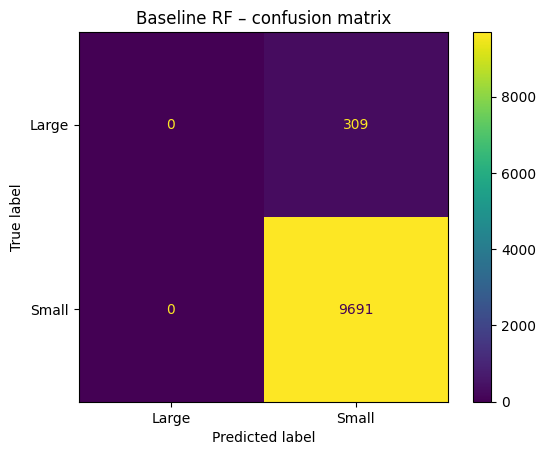

In [26]:
# baseline Random Forest (no class_weight)
# this is mainly to show how imbalance hurts Large-class metrics

rf_baseline = Pipeline([
    ("prep", preproc),
    ("model", RandomForestClassifier(
        n_estimators=100,
        max_depth=15,
        random_state=42,
        n_jobs=-1,
    )),
])

rf_baseline.fit(X_train, y_train)
y_pred_base = rf_baseline.predict(X_test)

print("Baseline Random Forest (no class_weight):\n")
print(classification_report(y_test, y_pred_base))

# confusion matrix for baseline
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_base)
plt.title("Baseline RF – confusion matrix")
plt.show()

**inference**

### Baseline Rf- no class weight : 

The baseline RF model was trained on the sampled dataset that was able to achieve high overall accuracy (97%) towards majority class i.e small Projects alone. The model reached a precision of 0.97, recall of 1.00 and F1=0.98 . This indicates that its almost perfectly predicted Small whenever they occured, but for the large class - precision and recall are 0.00 -- this means the model effectively never predicted Large class at all. As a recult, macro averaged F1 is only 0.49. These results highlifghted the need for addresal of class imbalance. In our case, the 97% accuracy was achieved because highly available projects were sampled, at a higher rate than the other lesser sampled classes. Hence, this cannot be relied upon without addressing the class imbalance issue.

Random Forest (class_weight='balanced'):

              precision    recall  f1-score   support

       Large       1.00      1.00      1.00       309
       Small       1.00      1.00      1.00      9691

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



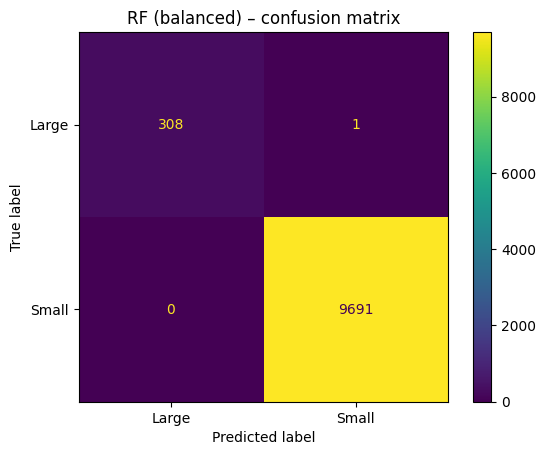

In [27]:
# Random Forest with class_weight='balanced'
# helps the rare Large class get more attention during training

rf_balanced = Pipeline([
    ("prep", preproc),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    )),
])

rf_balanced.fit(X_train, y_train)
y_pred_bal = rf_balanced.predict(X_test)

print("Random Forest (class_weight='balanced'):\n")
print(classification_report(y_test, y_pred_bal))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_bal)
plt.title("RF (balanced) – confusion matrix")
plt.show()

**inference**

#### RF (class_weight='balanced')

The RF model with class_weight="balanced" achieves perfect performance on the test set with an overall accuracy being 1.00 and both classes have precision and recall 1.0. Unlike, the baseline model - this run was able to identify all Large projects without sacrificing performance on the Small class. The macro-averaged F1 is also 1.00, this indicates that performance is uniformly strong across classes. 

This is a pretty near-to perfect solution on sampled subset alone, and can lead to model overfitting or benefitting froma small and relatively easy sample and was able to easily separate. IN practice, there would be requirement to validate using cross validation to ensure robustness when dealing with large datasets and not just sampled subsets. However, the balanced model was able to clearly demonstratethat reqeighting loss can substantially improve minory class-detection. 
